In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


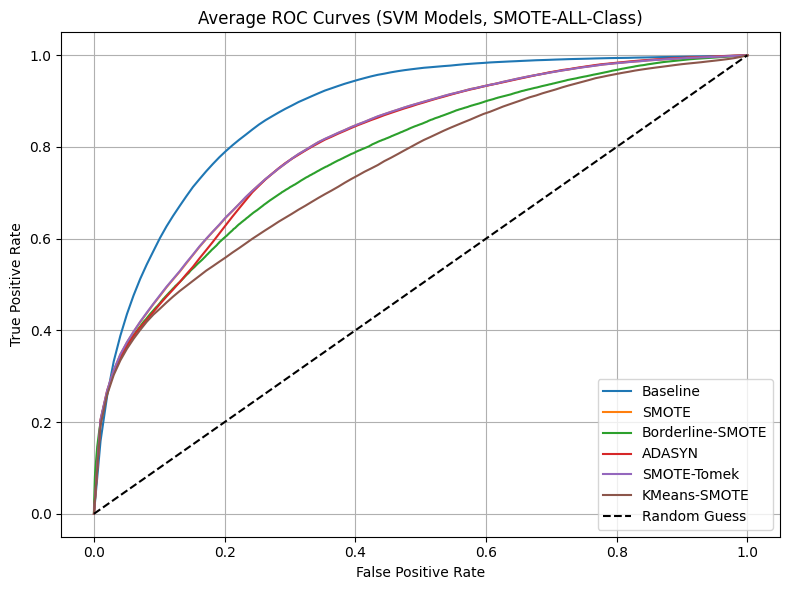

In [2]:
# ============================================
# 📈 Plot Mean ROC Curves (Auto-detect Class Column)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "Baseline": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/svm_baseline_roc_data.csv",
    "SMOTE": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/svm_smote_roc_points.csv",
    "Borderline-SMOTE": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/svm_sgd_borderline_roc_data.csv",
    "ADASYN": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/svm_adasyn_roc_points.csv",
    "SMOTE-Tomek": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/svm_tomek_roc_points.csv",
    "KMeans-SMOTE": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/svm_kmeans_roc_points.csv",
}

plt.figure(figsize=(8,6))
fpr_grid = np.linspace(0, 1, 100)

for label, path in files.items():
    df = pd.read_csv(path)
    cols = [c.lower() for c in df.columns]

    # --- กรณี multi-class ---
    if "class" in cols:
        class_col = df.columns[cols.index("class")]
        interp_tprs = []

        for cls, sub in df.groupby(class_col):
            sub = sub.sort_values("FPR").drop_duplicates("FPR")
            interp_tpr = np.interp(fpr_grid, sub["FPR"], sub["TPR"])
            interp_tprs.append(interp_tpr)

        mean_tpr = np.mean(interp_tprs, axis=0)
        plt.plot(fpr_grid, mean_tpr, label=label)

    # --- กรณี single ROC ---
    else:
        fpr_col = [c for c in df.columns if "fpr" in c.lower()][0]
        tpr_col = [c for c in df.columns if "tpr" in c.lower()][0]

        df = df.sort_values(fpr_col)
        plt.plot(df[fpr_col], df[tpr_col], label=label)

# เส้นอ้างอิง
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# ตกแต่งกราฟ
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Average ROC Curves (SVM Models, SMOTE-ALL-Class)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

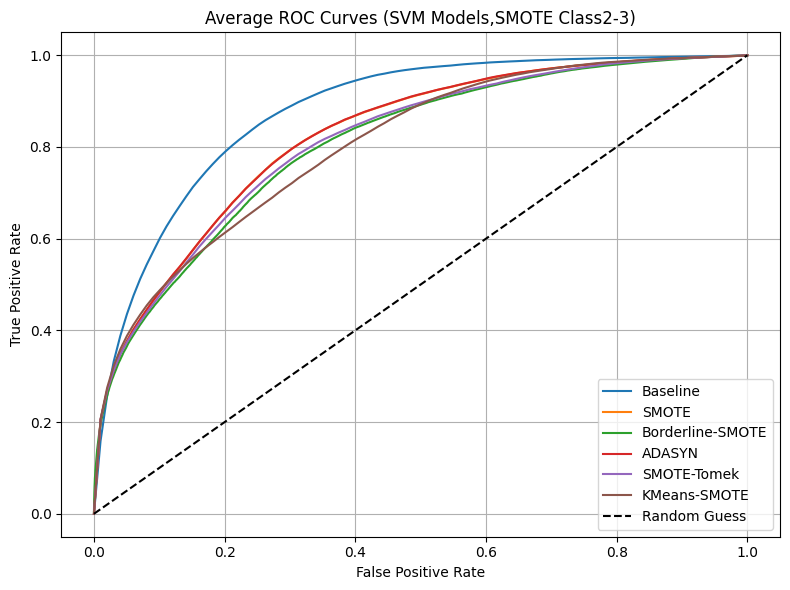

In [3]:
# ============================================
# 📈 Plot Mean ROC Curves (Auto-detect Class Column)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

files = {
    "Baseline": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/svm_baseline_roc_data.csv",
    "SMOTE": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/Class2-3/2-3svm_smote_roc_points.csv",
    "Borderline-SMOTE": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/Class2-3/2-3svm_sgd_borderline_roc_data.csv",
    "ADASYN": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/Class2-3/2-3svm_adasyn_roc_points.csv",
    "SMOTE-Tomek": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/ALL/svm_tomek_roc_points.csv",
    "KMeans-SMOTE": "/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/Class2-3/2-3svm_kmeans_roc_points.csv",
}

plt.figure(figsize=(8,6))
fpr_grid = np.linspace(0, 1, 100)

for label, path in files.items():
    df = pd.read_csv(path)
    cols = [c.lower() for c in df.columns]

    # --- กรณี multi-class ---
    if "class" in cols:
        class_col = df.columns[cols.index("class")]
        interp_tprs = []

        for cls, sub in df.groupby(class_col):
            sub = sub.sort_values("FPR").drop_duplicates("FPR")
            interp_tpr = np.interp(fpr_grid, sub["FPR"], sub["TPR"])
            interp_tprs.append(interp_tpr)

        mean_tpr = np.mean(interp_tprs, axis=0)
        plt.plot(fpr_grid, mean_tpr, label=label)

    # --- กรณี single ROC ---
    else:
        fpr_col = [c for c in df.columns if "fpr" in c.lower()][0]
        tpr_col = [c for c in df.columns if "tpr" in c.lower()][0]

        df = df.sort_values(fpr_col)
        plt.plot(df[fpr_col], df[tpr_col], label=label)

# เส้นอ้างอิง
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

# ตกแต่งกราฟ
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Average ROC Curves (SVM Models,SMOTE Class2-3)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()